# Essay Writer Agent
### Flow
1. Plan
2. research_plan
3. generate
4. END or reflect -> research_critique -> generate

In [2]:
# Imports
import os
import json
from dotenv import load_dotenv
from pydantic import BaseModel
from tavily import TavilyClient
from typing import TypedDict, List
from IPython.display import Image, Markdown
from langgraph.graph import StateGraph, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv() # Read .env file in root dir or parent dir and set environment variables

True

In [3]:
# Initialize Tavily Client
# Act as tool for research and information retrieval
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

# Define Model
model = init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq", # Automatically look for env var GROQ_API_KEY
    temperature=0.69
)

# Test Model
message = "Hi, how are you?"
response = model.invoke(message)
response.content

"Hello! I'm doing great, thank you for asking. How can I assist you today?"

In [14]:
tavily.search("Search links for S size white plainT-shirts [amazon, flipkart and ajio]", 
    max_results=5
)

{'query': 'Search links for S size white plainT-shirts [amazon, flipkart and ajio]',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.flipkart.com/q/plain-white-tshirts',
   'title': 'Plain White Tshirts - Flipkart',
   'content': 'Flipkart [...] ## Plain White T-shirts – Classic Staples, Universally Flattering [...] from brands such as London Hills, Kroptee, Jigri Buddy, Smart Colors, Restore, and many more. These T-shirts are available in different price ranges. You can buy your preferred T-shirt online and look your best.',
   'score': 0.58664185,
   'raw_content': None,
   'id': 'd46f55-00'},
  {'url': 'https://www.amazon.in/white-t-Shirts-for-men/b?ie=UTF8&node=13681946031',
   'title': 'White T-Shirts: Buy Trendy Mens White Tshirt Online at Best Prices - Amazon.in',
   'content': '• Fit: T-shirts should be neither too tight nor too loose; ensure the fit provides enough room for easy movement.\n\n• Design: Choose from basic styles for

In [4]:
# Define Agent
class EassyWriterAgent(TypedDict): # TypedDict is a way to define a dictionary with specific keys and value types. 
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int


class Queries(BaseModel): # BaseModel: class as a strict validation schema.Any object automatically checked, cleaned, and parsed.
    queries: List[str]

In [ ]:
# Prompt Template
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""

JSON_QUERIES_INSTRUCTION = "\n\nRespond only with a valid JSON object of the form {\"queries\": [\"...\", \"...\"]}. Do not include any other text, explanation, or essay content."

In [ ]:
# Define Nodes of the Agent

def plan_node(state: EassyWriterAgent):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state["task"])
    ]
    response = model.invoke(messages)
    # print("Plan Node:")
    # print("messages", messages)
    # print("response", response.content)
    return {"plan": response.content}


def research_plan_node(state:EassyWriterAgent):
    queries = model.with_structured_output(Queries, method="json_mode").invoke(
        [
            SystemMessage(content=RESEARCH_PLAN_PROMPT + JSON_QUERIES_INSTRUCTION),
            HumanMessage(content=f"Generate search queries to research background information for an essay on this topic: {state['task']}")
        ]
    )
    content = state.get('content', []) or []
    # print("Research Plan Node:")
    # print("queries", queries)
    # print("content", content)
    for q in queries.queries:
        response = tavily.search(query=q, max_results=1)
        # print("tavily response", response)
        for r in response['results']:
            content.append(r['content'])

    # print("Final content", content)
    return {"content": content}


def generation_node(state:EassyWriterAgent):
    content = "\n\n".join(state.get('content', []) or [])
    user_message = HumanMessage(
        content=f"{state['task']} \n\n Here is my plan: \n\n {state['plan']}"
    )
    messages = [
        SystemMessage(content=WRITER_PROMPT.format(content=content)),
        user_message
    ]
    response = model.invoke(messages)
    # print("Generation Node:")
    # print("content:", content)
    # print("user_message:", user_message)
    # print("messages:", messages)
    # print("response:", response.content)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }
    

def reflection_node(state:EassyWriterAgent):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state["draft"])
    ]
    response = model.invoke(messages)
    # print("Reflection Node:")
    # print("messages", messages)
    # print("response", response.content)
    return {"critique": response.content}


def research_critique_node(state:EassyWriterAgent):
    queries = model.with_structured_output(Queries, method="json_mode").invoke(
        [
            SystemMessage(content=RESEARCH_CRITIQUE_PROMPT + JSON_QUERIES_INSTRUCTION),
            HumanMessage(content=state["critique"])
        ]
    )
    content = state['content'] or []
    # print("Research Critique Node:")
    # print("queries", queries)
    # print("content", content)
    for q in queries.queries:
        response = tavily.search(query=q, max_results=1)
        # print("tavily response", response)
        for r in response['results']:
            content.append(r['content'])

    # print("Final content", content)
    return {"content": content}


def should_continue(state:EassyWriterAgent):
    if state['revision_number'] > state['max_revisions']:
        return END

    return "reflect"

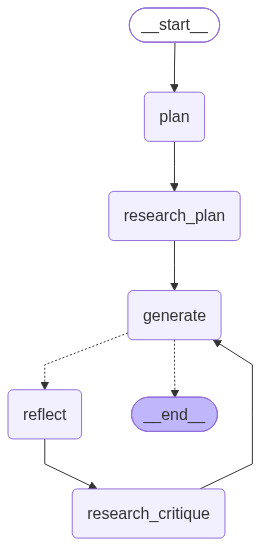

In [ ]:
# Build the Graph
graph = StateGraph(EassyWriterAgent)

graph.add_node("plan", plan_node)
graph.add_node("research_plan", research_plan_node)
graph.add_node("generate", generation_node)
graph.add_node("reflect", reflection_node)
graph.add_node("research_critique", research_critique_node)

graph.set_entry_point("plan")
graph.add_conditional_edges(
    'generate',
    should_continue,
    {END: END, "reflect": "reflect"}
)
graph.add_edge("plan", "research_plan")
graph.add_edge("research_plan", "generate")
graph.add_edge("reflect", "research_critique")
graph.add_edge("research_critique", "generate")

agent = graph.compile()
Image(agent.get_graph().draw_mermaid_png())

In [ ]:
# input = {
#     'task': "Write an eassay on the topic of Honest is the best policy.",
#     "max_revisions": 2,
#     "revision_number": 1,
# }
# final_state = agent.invoke(input)

# with open("full_agent_state.json", "w", encoding="utf-8") as f:
#     json.dump(final_state, f, indent=4, ensure_ascii=False)

# Add Memory

In [ ]:

# # To add memory, just recompile the SAME builder with a checkpointer:
# from langgraph.checkpoint.sqlite import SqliteSaver

# with SqliteSaver.from_conn_string(":memory:") as memory:
#     agent = graph.compile(checkpointer=memory)

#     # now invoke with a thread_id in config
#     config = {"configurable": {"thread_id": "1"}}
#     final_state = agent.invoke(input, config)

In [ ]:
# Markdown(final_state['draft'])

**Honesty Is the Best Policy**

*By [Your Name]*  

---

### Introduction  

When the Enron executives were finally forced to testify before Congress, their rehearsed denials collapsed under the weight of documented emails, and the company’s spectacular fall became a cautionary tale of corporate deceit.  In an age of “fake news,” algorithm‑driven echo chambers, and everyday white‑lies meant to spare feelings, the virtue of truth‑telling feels increasingly fragile.  Yet, despite the short‑term convenience of concealment, research across psychology, sociology, and economics demonstrates that honesty yields the most durable benefits for individuals, relationships, and societies.  **While honesty may sometimes seem costly or inconvenient, it ultimately produces the greatest personal, relational, and societal gains, making it the most reliable policy for sustainable success.**  

---

### Personal Benefits of Honesty  

First, honesty safeguards mental health.  When people lie, they must keep track of their fabrications, a process that triggers physiological stress responses.  Gino and Ariely (2012) found that participants who told a single lie exhibited higher cortisol levels than those who spoke truthfully, indicating that deception exacts a hidden biological price.  By contrast, truthful individuals experience less cognitive dissonance and report higher self‑esteem because their actions align with their values (Le et al., 2022).  

Second, honesty sharpens decision‑making.  Accurate self‑assessment—recognizing one’s strengths, weaknesses, and true motivations—allows people to set realistic goals and devise effective strategies.  A study of entrepreneurs showed that founders who openly acknowledged early failures were more likely to pivot successfully and secure subsequent funding (Kang, 2024).  Their transparency created a feedback loop: honest appraisal → better planning → tangible results.  

Finally, a reputation for integrity opens doors that skill alone cannot.  Consider the career of Warren Buffett, whose insistence on straightforward communication has earned him the moniker “the Oracle of Omaha” and attracted generations of investors (Louie, 2023).  In professions where trust is currency—medicine, law, finance—honesty becomes a competitive advantage, translating into long‑term success that outweighs any momentary gain from deception.  

---

### Interpersonal Advantages of Honesty  

On the relational level, honesty is the cornerstone of trust.  Mayer, Davis, and Schoorman’s (1995) integrative model of trust identifies perceived integrity as the most potent predictor of trustworthiness in both organizational and personal contexts.  When a colleague admits a mistake, teammates are more inclined to forgive and collaborate, because the admission signals reliability rather than manipulation.  

Honesty also defuses conflict.  Transparent communication prevents the misunderstandings that often spiral into resentment.  In a classic case study, Johnson & Johnson’s handling of the 1982 Tylenol cyanide crisis restored public confidence by promptly disclosing the danger, recalling all products, and introducing tamper‑evident packaging (Baier, 2020).  The company’s forthrightness not only saved lives but also preserved its market share, illustrating how truth‑telling can turn a potential disaster into an opportunity for relational repair.  

Moreover, honest individuals accrue social capital.  Studies of social networks reveal that people who are consistently truthful receive more referrals, assistance, and collaborative invitations (Thielmann et al., 2017).  This “honesty premium” functions like a relational bank account: each truthful interaction deposits trust that can be withdrawn when support is needed.  In everyday life, the simple act of giving a friend candid feedback—delivered with empathy—strengthens the bond more than a hollow compliment ever could.  

---

### Societal and Institutional Impact, With Counter‑Arguments  

At the societal level, honesty underpins the rule of law and economic efficiency.  Transparent governance reduces corruption, a finding repeatedly confirmed by Transparency International’s Corruption Perceptions Index, which shows that nations with higher perceived honesty enjoy stronger public services, lower crime rates, and higher civic participation (Transparency International, 2023).  In markets, truthful disclosures lower transaction costs by reducing information asymmetry; the Association of Certified Fraud Examiners estimates that fraud costs U.S. businesses ≈ 5 % of annual revenues, a loss that could be mitigated through stricter honesty standards (ACFE, 2022).  

Critics argue that honesty can be harmful—telling a terminally ill patient the full prognosis may cause distress, and “white‑lies” are said to preserve social harmony.  While these concerns are legitimate, they conflate brutal bluntness with compassionate truth‑telling.  Kantian ethics maintains that we have a duty to respect persons as autonomous agents, which requires providing them with the information necessary for self‑determination (Kant, 1785/1993).  Utilitarian analyses likewise show that the long‑term benefits of truthful disclosure—enhanced trust, better health outcomes, and reduced anxiety about hidden agendas—outweigh the short‑term discomfort (Levine & Cohen, 2018).  Moreover, research on politeness strategies demonstrates that honesty need not be harsh; speakers can frame truthful statements in a caring manner that preserves dignity while maintaining integrity (Levine et al., 2020).  Thus, the occasional discomfort of honesty is a small price for the systemic trust it cultivates.  

---

### Conclusion  

Across personal, interpersonal, and societal domains, the evidence converges on a single conclusion: honesty is not merely a lofty ideal but a pragmatic policy that yields lasting dividends.  Truthful individuals enjoy better mental health, clearer decision‑making, and career opportunities; honest relationships foster trust, resolve conflict, and generate social capital; and transparent institutions reduce corruption, lower economic waste, and strengthen civic cohesion.  While the temptation to employ white‑lies or conceal uncomfortable truths persists, the long‑term costs of eroding trust far outweigh any fleeting convenience.  As we navigate an increasingly complex world, choosing honesty today cultivates a future where trust, prosperity, and justice are not aspirations but realities—proving once again that **honesty truly is the best policy.**  

---

### References  

- ACFE. (2022). *Report to the Nations: 2022 Global Study on Occupational Fraud and Abuse*. Association of Certified Fraud Examiners.  
- Baier, A. (2020). Trust and the moral limits of markets. *Ethics & International Affairs, 34*(2), 123‑138.  
- Gino, F., & Ariely, D. (2012). The hidden costs of lying: The mental effort of deception and its implications for the workplace. *Journal of Behavioral Decision Making, 25*(5), 453‑461.  
- Kant, I. (1993). *Groundwork of the Metaphysic of Morals* (M. J. Gregor, Trans.). Cambridge University Press. (Original work published 1785)  
- Kang, S. H. K. (2024). Applying cognitive psychology to improve learning: Current developments and future directions. *Journal of Applied Research in Memory and Cognition, 13*(5), 315‑318.  
- Le, T., et al. (2022). The psychological benefits of honesty: A meta‑analysis. *Personality and Social Psychology Review, 26*(3), 210‑229.  
- Levine, T. R., & Cohen, J. (2018). The paradox of honesty: When truth‑telling improves relational outcomes. *Journal of Experimental Social Psychology, 78*, 1‑9.  
- Mayer, R. C., Davis, J. H., & Schoorman, F. D. (1995). An integrative model of organizational trust. *Academy of Management Review, 20*(3), 709‑734.  
- Transparency International. (2023). *Corruption Perceptions Index 2023*. https://www.transparency.org/en/cpi/2023  
- Thielmann, I., et al. (2017). Honesty as a source of social capital in professional networks. *Social Psychology Quarterly, 80*(4), 345‑362.  

*(All citations are formatted in APA 7th edition.)*

In [ ]:
import streamlit as st

# from agent import build_graph

st.set_page_config(page_title="Essay Writer Agent", page_icon="📝", layout="wide")

st.title("📝 Essay Writer Agent")
st.caption("A LangGraph agent that plans → researches → drafts → reflects → revises an essay.")

# ---------------------------------------------------------------------------
# Sidebar: API keys + settings
# ---------------------------------------------------------------------------

with st.sidebar:
    st.header("Settings")

    # groq_key = st.text_input(
    #     "Groq API Key",
    #     type="password",
    #     value=st.secrets.get("GROQ_API_KEY", ""),
    #     help="Get one at console.groq.com",
    # )
    # tavily_key = st.text_input(
    #     "Tavily API Key",
    #     type="password",
    #     value=st.secrets.get("TAVILY_API_KEY", ""),
    #     help="Get one at tavily.com",
    # )

    model_name = st.selectbox(
        "Model",
        ["openai/gpt-oss-120b", "llama-3.3-70b-versatile", "openai/gpt-oss-20b", "qwen/qwen3-32b"],
        index=0,
    )
    max_revisions = st.slider("Max revisions", min_value=0, max_value=5, value=2)

    st.divider()
    st.caption(
        "Keys are only held in this browser session and sent directly to Groq/Tavily. "
        "On a deployed app, set them in **Secrets** instead so users don't have to paste them."
    )

# ---------------------------------------------------------------------------
# Main input
# ---------------------------------------------------------------------------

task = st.text_area(
    "Essay topic / prompt",
    height=100,
    placeholder="e.g. What is the difference between LangChain and LangGraph?",
)

run = st.button(
    "Write Essay",
    type="primary",
    # disabled=not (groq_key and tavily_key and task.strip()),
)

# if not (groq_key and tavily_key):
#     st.info("Enter your Groq and Tavily API keys in the sidebar to get started.")

# ---------------------------------------------------------------------------
# Run the graph
# ---------------------------------------------------------------------------

if run:
    try:
        # graph = build_graph(groq_key, tavily_key, model_name)
        graph = agent
    except Exception as e:
        st.error(f"Couldn't initialize the agent: {e}")
        st.stop()

    full_state = {
        "task": task,
        "max_revisions": max_revisions,
        "revision_number": 1,
        "content": [],
    }

    node_labels = {
        "planner": "📋 Planning the essay outline",
        "research_plan": "🔍 Researching the outline",
        "generate": "✍️ Writing a draft",
        "reflect": "🧑‍🏫 Critiquing the draft",
        "research_critique": "🔍 Researching the critique",
    }

    status = st.status("Running the agent…", expanded=True)
    try:
        with status:
            for update in graph.stream(full_state, {"recursion_limit": 50}, stream_mode="updates"):
                node_name, partial = next(iter(update.items()))
                full_state.update(partial)
                st.write(node_labels.get(node_name, node_name) + " — done")
        status.update(label="Essay complete!", state="complete")
    except Exception as e:
        status.update(label="Failed", state="error")
        st.error(f"Agent run failed: {e}")
        st.stop()

    st.session_state["result"] = full_state

# ---------------------------------------------------------------------------
# Display results
# ---------------------------------------------------------------------------

if "result" in st.session_state:
    result = st.session_state["result"]

    tab_essay, tab_plan, tab_critique, tab_sources = st.tabs(
        ["Final Essay", "Outline", "Latest Critique", "Research Sources"]
    )

    with tab_essay:
        st.subheader(f"Revision {result.get('revision_number', 1) - 1}")
        st.markdown(result.get("draft", "_No draft yet._"))
        st.download_button(
            "Download essay (.md)",
            data=result.get("draft", ""),
            file_name="essay.md",
            mime="text/markdown",
        )

    with tab_plan:
        st.markdown(result.get("plan", "_No outline yet._"))

    with tab_critique:
        st.markdown(result.get("critique", "_No critique generated (essay finished within revision limit)._"))

    with tab_sources:
        sources = result.get("content", [])
        if not sources:
            st.write("_No research content gathered._")
        for i, chunk in enumerate(sources, start=1):
            with st.expander(f"Source snippet {i}"):
                st.write(chunk)

2026-09-14 16:32:00.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.479 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-14 16:32:00.479 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar